In [1]:
import numpy as np
%load_ext autoreload
%autoreload 2
from utils import plot_violinplot, plot_boxplot, line_plot, scatter_plot, line_and_bar_plot, line_and_bar_plot2, line_and_bar_plot3

def pad_to_max_length(data, max_len=1000, value=np.nan):
    padded_data = [[sublst + [value] * (max_len - len(sublst)) for sublst in lst] for lst in data]
    return np.array(padded_data)

queries = [0, 99, 199, 299, 399, 499, 599, 699, 799, 899, 999]
methods = [0, 1, 3, 4, 2, 6, 5, 7]

labels = ["OBD", 
          "GBD",
          "Honest Beacon", 
          "Baseline", 
          "Query Budget", 
          "Random", 
          "Strategic Flipping",
          "Real Time Strategic Flipping",]

Adding RTF

In [2]:
import pickle
with open('./results/rtf.pkl', 'rb') as f:
    data_dict = pickle.load(f)

rtf_utilities = data_dict['utilities2']
rtf_beacon_rewards = data_dict['beacon_rewards']

In [3]:
len(rtf_utilities), len(rtf_beacon_rewards)

(3, 3)

In [4]:
with open('./results/rtf_random.pkl', 'rb') as f:
    data_dict = pickle.load(f)

rtf_random_utilities = data_dict['utilities2']
rtf_random_beacon_rewards = data_dict['beacon_rewards']

In [5]:
import pickle
line_data_list=[]
bar_data_list=[]
# Load the data from the pickle file
with open('./results/v2/optimal.pkl', 'rb') as f:
    data_dict = pickle.load(f)

utilities2 = data_dict['utilities2']
beacon_rewards = data_dict['beacon_rewards']
utilities2.append(rtf_utilities[0])
beacon_rewards.append(rtf_beacon_rewards[0])
padded_utilities = pad_to_max_length(utilities2, value=0)[methods]
padded_beacon_rewards = pad_to_max_length(beacon_rewards)[methods]
nan_count = np.isnan(padded_beacon_rewards).sum(axis=1)
line_data_list.append(np.nanmean(padded_utilities, axis=1)[:, queries])
bar_data_list.append(nan_count[:,queries])

In [6]:
# Load the data from the pickle file
with open('./results/v2/SBA.pkl', 'rb') as f:
    data_dict = pickle.load(f)

utilities2 = data_dict['utilities2']
beacon_rewards = data_dict['beacon_rewards']
utilities2.append(rtf_utilities[1])
beacon_rewards.append(rtf_beacon_rewards[1])
padded_utilities = pad_to_max_length(utilities2, value=0)[methods]
padded_beacon_rewards = pad_to_max_length(beacon_rewards)[methods]
nan_count = np.isnan(padded_beacon_rewards).sum(axis=1)
line_data_list.append(np.nanmean(padded_utilities, axis=1)[:, queries])
bar_data_list.append(nan_count[:,queries])

# Load the data from the pickle file
with open('./results/GBA20K.pkl', 'rb') as f:
    data_dict = pickle.load(f)

utilities2 = data_dict['utilities2']
beacon_rewards = data_dict['beacon_rewards']
utilities2.append(rtf_utilities[2])
beacon_rewards.append(rtf_beacon_rewards[2])
padded_utilities = pad_to_max_length(utilities2, value=0)[methods]
padded_beacon_rewards = pad_to_max_length(beacon_rewards)[methods]
nan_count = np.isnan(padded_beacon_rewards).sum(axis=1)
line_data_list.append(np.nanmean(padded_utilities, axis=1)[:, queries])
bar_data_list.append(nan_count[:,queries])

In [7]:
len(utilities2)

8

In [8]:
with open('./results/v2/random.pkl', 'rb') as f:
    data_dict = pickle.load(f)

utilities2 = data_dict['utilities2']
beacon_rewards = data_dict['beacon_rewards']
utilities2.append(rtf_random_utilities[0])
beacon_rewards.append(rtf_random_beacon_rewards[0])
padded_utilities = pad_to_max_length(utilities2, value=0)[methods]
padded_beacon_rewards = pad_to_max_length(beacon_rewards)[methods]
nan_count = np.isnan(padded_beacon_rewards).sum(axis=1)
line_data_list.append(np.nanmean(padded_utilities, axis=1)[:, queries])
bar_data_list.append(nan_count[:,queries])

In [46]:
with open('./results/binary/ref-10.pkl', 'rb') as f:
    data_dict = pickle.load(f)

In [23]:
with open('./results/v2/random.pkl', 'rb') as f:
    data_dict = pickle.load(f)

In [40]:
beacon_rewards = data_dict['beacon_rewards']
beacon_rewards.append(rtf_random_beacon_rewards[0])

In [48]:
print(len(data_dict['beacon_rewards'][0]))

29


In [39]:
test = pad_to_max_length(utilities2, value=0)[methods]
len(test)

8

In [54]:
for item in data_dict['beacon_rewards'][2]: print(len(item))

1
1
1
1
2
1
4
1
1
1
1
1
2
2
1
1
1
1
1
2
2
1
1
2
1
2
2
1
2


In [21]:
line_data_list[0]

array([[1.        , 0.89606378, 0.93408052, 0.94962373, 0.95874236,
        0.96459435, 0.96905199, 0.97249517, 0.97525598, 0.9774316 ,
        0.97913676],
       [1.        , 0.96638566, 0.98272756, 0.98832403, 0.99107536,
        0.9927667 , 0.99388391, 0.99468879, 0.99531394, 0.99580813,
        0.99620432],
       [1.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        ],
       [1.        , 0.27482759, 0.45741379, 0.52333333, 0.5562931 ,
        0.57606897, 0.58925287, 0.59866995, 0.60573276, 0.61122605,
        0.61562069],
       [1.        , 0.22551724, 0.20137931, 0.17712644, 0.13982759,
        0.11662069, 0.09781609, 0.08399015, 0.07349138, 0.06532567,
        0.0587931 ],
       [1.        , 0.1537931 , 0.15293103, 0.15505747, 0.15577586,
        0.156     , 0.15609195, 0.15566502, 0.15590517, 0.15547893,
        0.15455172],
       [1.        , 0.23896552, 0.24517241, 0.24666667, 0.

In [9]:
len(padded_utilities)

8

In [10]:
len(labels)

8

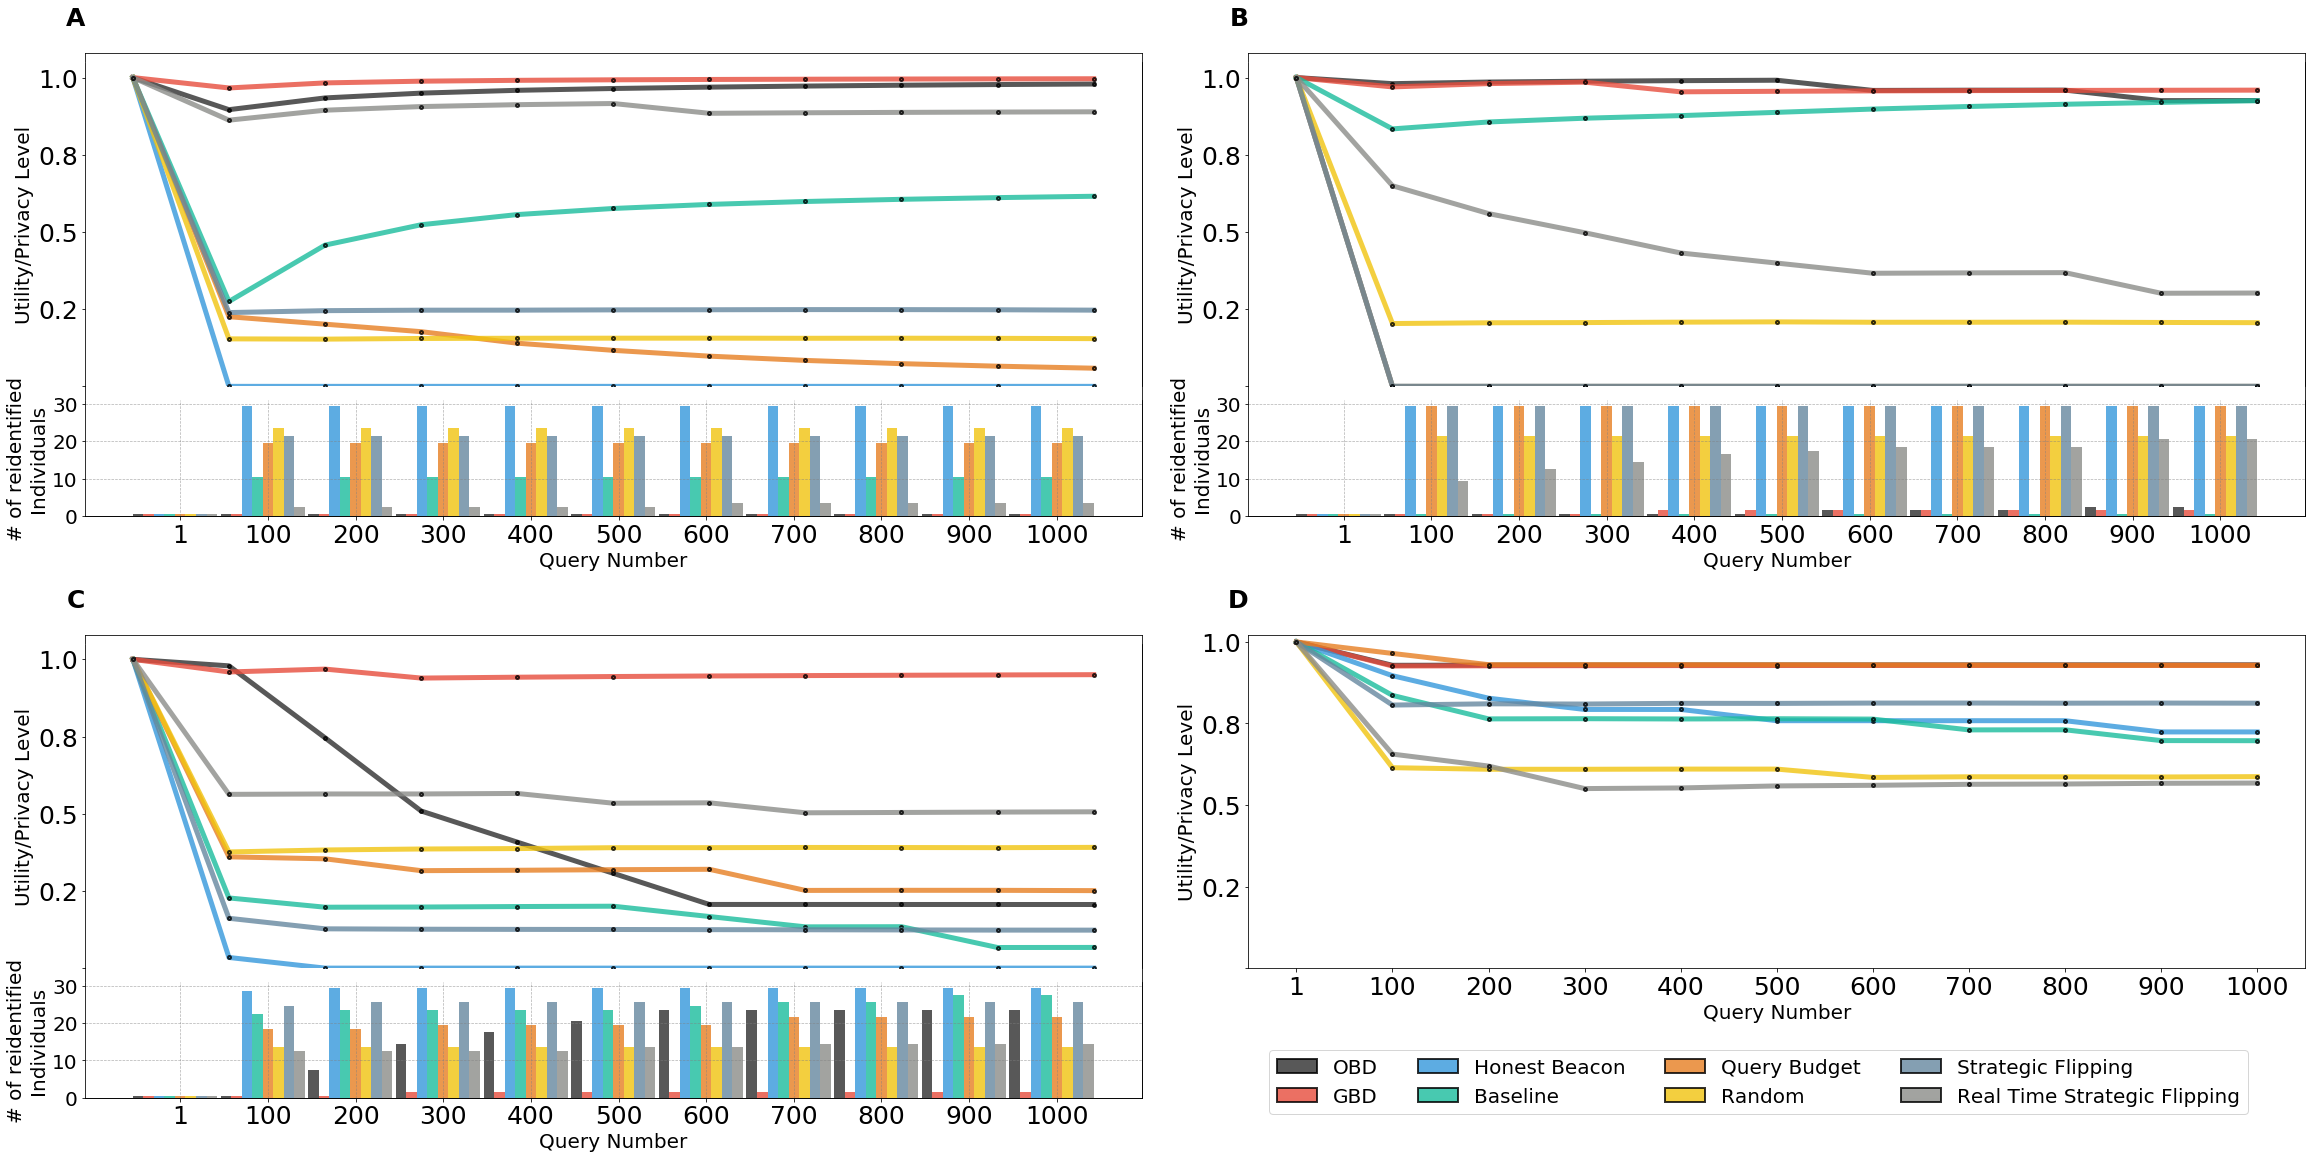

In [12]:
line_and_bar_plot3(np.array(line_data_list), np.array(bar_data_list), labels, ylabel_line="Utility/Privacy Level", ylabel_bar="# of reidentified\nIndividuals")